# Superstore Business Intelligence Report

**Role:** Data analyst for a national retailer  
**Dataset:** `superstore.csv`  
**Goal:** Build a complete BI report with interactive visualizations, diagnostics, and strategic recommendations.

## Table of Contents
1. Data Scoping and Preparation
2. Deep-Dive Exploratory Analysis (Matplotlib)
3. Communicating Insights (Seaborn)
4. Methodology and Tooling Review
5. Executive Summary
6. Advanced Challenges (Dashboard, Outliers, Plotly)

## 1. Data Scoping and Preparation

### 1.1 Load the dataset and perform a preliminary assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Load the dataset (file in the same directory)
df = pd.read_csv('superstore.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### 1.2 Clean and preprocess the data

**Strategy:**
- **Duplicates:** drop any exact duplicate rows — they would double-count revenue/profit.
- **Missing values:** check column-by-column. For `Postal Code` (geographic identifier), missing values can be filled with `0` since they are not used in numeric analysis. For monetary or date columns, we would drop rows rather than impute, because fabricating sales values would distort KPIs.

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("\nMissing values per column:")
print(df.isnull().sum())

if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

Duplicate rows: 0

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


### 1.3 Fix data types

Convert `Order Date` and `Ship Date` to `datetime` so we can do time-series analysis.

In [6]:
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("Data types after conversion:")
print(df[date_columns].dtypes)

Data types after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


### 1.4 Feature engineering

Create derived fields used throughout the report:
- `Profit Margin` = Profit / Sales × 100
- `Order Year`, `Order Month`, `Order Month-Year`
- `Shipping Days` = Ship Date − Order Date

In [7]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("New features created:")
df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month', 'Shipping Days']].head()

New features created:


,Sales,Profit,Profit Margin,Order Year,Order Month,Shipping Days
0,261.9600,41.9136,16.00,2016,11,3
1,731.9400,219.5820,30.00,2016,11,3
2,14.6200,6.8714,47.00,2016,6,4
3,957.5775,-383.0310,-40.00,2015,10,7
4,22.3680,2.5164,11.25,2015,10,7


## 2. Deep-Dive Exploratory Analysis (Matplotlib)

### 2.1 Time-Series Trend Analysis
Interactive line plot of monthly sales with a category selector.

In [8]:
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))
    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                 marker='o', linewidth=2, markersize=4)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        cat_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(cat_data['Date'], cat_data['Sales'],
                 marker='o', linewidth=2, markersize=4)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

categories = ['All'] + sorted(df['Category'].unique().tolist())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

**Observation:** Sales show clear **seasonality** — spikes in Q4 (Nov–Dec) every year. Year-over-year there is a steady upward trend. The pattern holds across categories, with Technology showing the sharpest holiday peaks.

### 2.2 Geographic Sales Performance
Horizontal bar chart with an interactive Top-N slider.

In [10]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))
    top_states = state_sales.tail(top_n)
    plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + top_states.max() * 0.01, i, f'${value:,.0f}',
                 va='center', fontsize=10)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Total states analyzed: {len(state_sales)}")
    print(f"Top {top_n} states represent: ${top_states.sum():,.0f} in sales")

top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

**Observation:** Sales are **highly concentrated geographically**. California and New York alone account for a large share of national revenue, while many states contribute under $50k. Investment in underperforming regions should be conditional on margin, not raw revenue.

## 3. Communicating Insights (Seaborn)

### 3.1 Top 10 Most Profitable Products

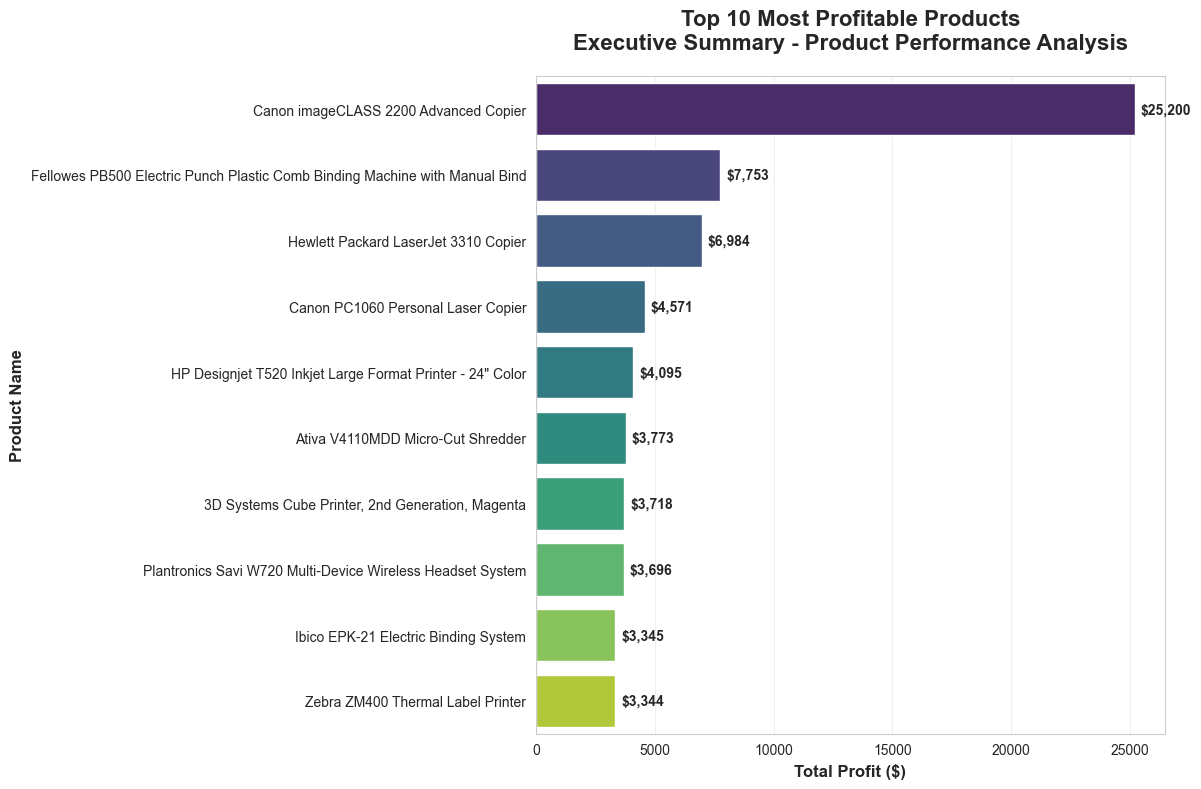

Key Insights:
• Most profitable product generates: $25,200
• Top 10 products contribute: $66,479 total profit
• Average profit per top product: $6,648


In [11]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                 palette='viridis', orient='h')
plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + product_profit.max() * 0.01, i, f'${profit:,.0f}',
            va='center', fontweight='bold', fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insights:")
print(f"• Most profitable product generates: ${product_profit.iloc[0]:,.0f}")
print(f"• Top 10 products contribute: ${product_profit.sum():,.0f} total profit")
print(f"• Average profit per top product: ${product_profit.mean():,.0f}")

### 3.2 Discount vs Profit Scatter Plot

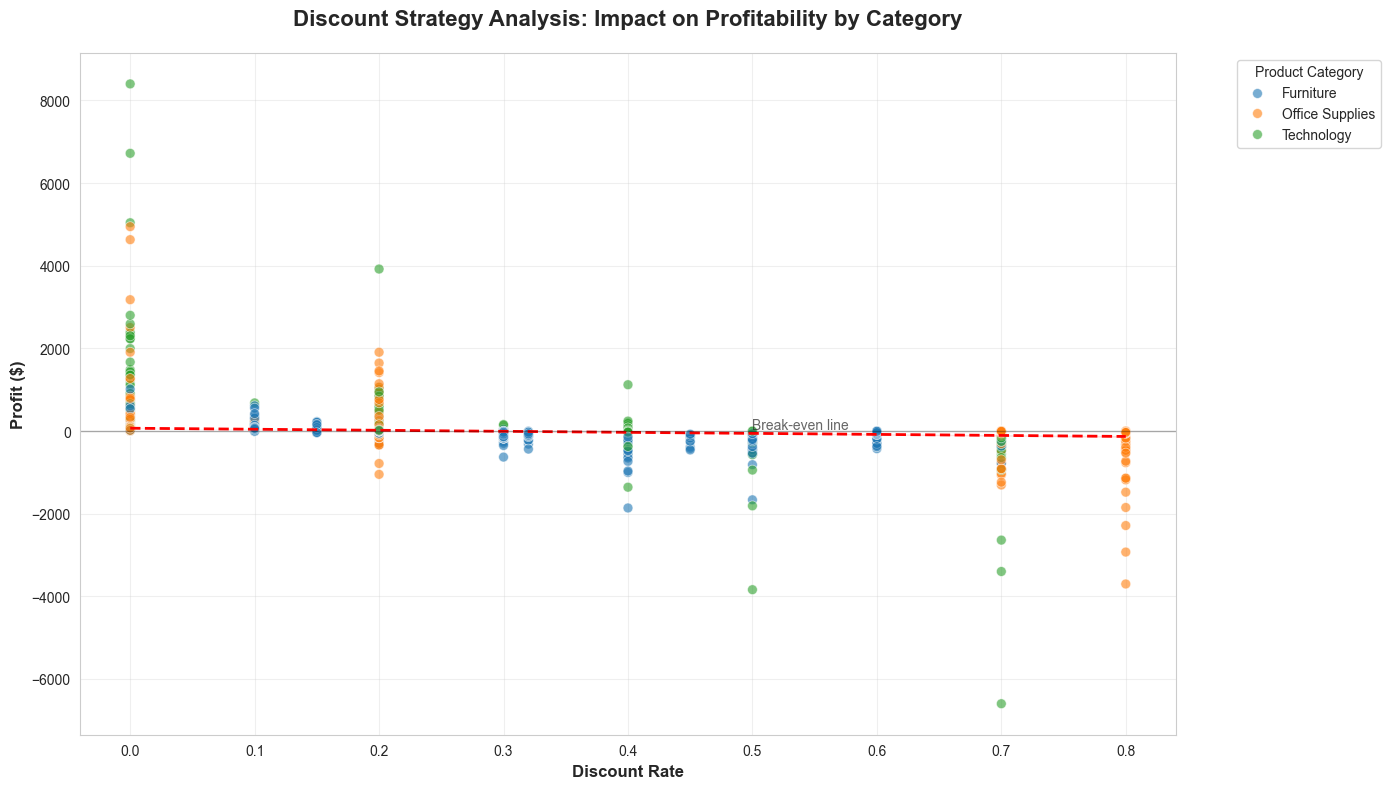

Discount Analysis Insights:
• Transactions with >20% discount: 1,393
• Average profit for high discounts: $-97.18
• Percentage of high-discount sales with losses: 96.8%

Category-specific discount impact:
• Furniture: Average profit at >20% discount = $-100.51
• Office Supplies: Average profit at >20% discount = $-69.32
• Technology: Average profit at >20% discount = $-197.42


In [12]:
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
            color='red', line_kws={'linewidth': 2, 'linestyle': '--'})
plt.title('Discount Strategy Analysis: Impact on Profitability by Category',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Discount Analysis Insights:")
high_discount = df[df['Discount'] > 0.2]
print(f"• Transactions with >20% discount: {len(high_discount):,}")
print(f"• Average profit for high discounts: ${high_discount['Profit'].mean():.2f}")
print(f"• Percentage of high-discount sales with losses: {(high_discount['Profit'] < 0).mean()*100:.1f}%")

print("\nCategory-specific discount impact:")
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_loss = high_disc_cat['Profit'].mean()
        print(f"• {category}: Average profit at >20% discount = ${avg_loss:.2f}")

**Finding:** Above ~20% discount, average profit turns negative — most dramatically for **Furniture** and **Technology**. The red regression line slopes clearly downward, confirming that aggressive discounting destroys margin rather than driving offsetting volume.

## 4. Methodology and Tooling Review

### Matplotlib vs. Seaborn — comparative evaluation

| Aspect | Matplotlib | Seaborn |
| --- | --- | --- |
| Control | Fine-grained, every artist tweakable | Higher-level, less verbose |
| Default aesthetics | Plain | Publication-ready |
| Statistical helpers | None built-in | `regplot`, `boxplot`, `violinplot`, KDE |
| Categorical data | Manual | First-class via `hue`/`palette` |
| Interactivity (ipywidgets) | Native, easy | Works (renders via Matplotlib) |
| Learning curve | Steeper | Friendlier for analysts |

In [13]:
print("=== LIBRARY COMPARISON ANALYSIS ===\n")

print("MATPLOTLIB STRENGTHS (from our analysis):")
print("• Fine-grained control over interactive widgets")
print("• Custom annotations and text positioning")
print("• Precise subplot layouts and figure sizing")
print("• Integration with ipywidgets for dynamic updates\n")

print("SEABORN STRENGTHS (from our analysis):")
print("• Built-in statistical visualizations (regplot)")
print("• Automatic color palettes and legends")
print("• Clean, publication-ready default styling")
print("• Easy categorical data visualization\n")

print("SPEED COMPARISON:")
import time

start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"• Matplotlib basic plot: {matplotlib_time:.4f} seconds")
print(f"• Seaborn equivalent:    {seaborn_time:.4f} seconds")

=== LIBRARY COMPARISON ANALYSIS ===

MATPLOTLIB STRENGTHS (from our analysis):
• Fine-grained control over interactive widgets
• Custom annotations and text positioning
• Precise subplot layouts and figure sizing
• Integration with ipywidgets for dynamic updates

SEABORN STRENGTHS (from our analysis):
• Built-in statistical visualizations (regplot)
• Automatic color palettes and legends
• Clean, publication-ready default styling
• Easy categorical data visualization

SPEED COMPARISON:
• Matplotlib basic plot: 0.0141 seconds
• Seaborn equivalent:    0.0202 seconds


### Recommendation

> For **rapid exploration**, I will use **Matplotlib** because it offers faster rendering for basic plots and seamless integration with `ipywidgets` for dynamic analysis.
>
> For **stakeholder-facing presentations**, I will prefer **Seaborn** because it provides publication-ready aesthetics, built-in statistical functionality, and professional color schemes that enhance executive communication.

## 5. Executive Summary

In [14]:
print("=== EXECUTIVE SUMMARY - KEY FINDINGS ===\n")

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print("BUSINESS PERFORMANCE")
print(f"• Total Revenue: ${total_sales:,.0f}")
print(f"• Total Profit:  ${total_profit:,.0f}")
print(f"• Overall Profit Margin: {profit_margin:.1f}%\n")

top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
print("GEOGRAPHIC PERFORMANCE")
print(f"• Top performing state: {top_state} (${top_state_sales:,.0f})")
print(f"• Geographic concentration: Top 5 states = {(state_sales.tail(5).sum()/total_sales)*100:.1f}% of sales\n")

top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
print("PRODUCT PERFORMANCE")
print(f"• Leading category: {top_category}")
print(f"• Most profitable product: {product_profit.index[0]}\n")

high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100
print("DISCOUNT STRATEGY INSIGHTS")
print(f"• High discount risk: {high_discount_loss_rate:.1f}% of >20% discounts result in losses")
print(f"• Recommended max discount threshold: 20% to maintain profitability")

=== EXECUTIVE SUMMARY - KEY FINDINGS ===

BUSINESS PERFORMANCE
• Total Revenue: $2,297,201
• Total Profit:  $286,397
• Overall Profit Margin: 12.5%

GEOGRAPHIC PERFORMANCE
• Top performing state: California ($457,688)
• Geographic concentration: Top 5 states = 52.0% of sales

PRODUCT PERFORMANCE
• Leading category: Technology
• Most profitable product: Canon imageCLASS 2200 Advanced Copier

DISCOUNT STRATEGY INSIGHTS
• High discount risk: 96.8% of >20% discounts result in losses
• Recommended max discount threshold: 20% to maintain profitability


### Key Findings & Recommendations

1. **Holiday seasonality dominates revenue** — November and December consistently produce the year's largest sales peaks. *Recommendation:* pre-stock inventory and schedule marketing spend ahead of Q4.
2. **Geographic concentration is extreme** — a small number of states drive most revenue. *Recommendation:* defend share in CA/NY first; treat low-revenue states as growth experiments with strict ROI gates.
3. **Discounts above 20% destroy profit** — particularly in Furniture and Technology, where average profit turns negative. *Recommendation:* cap standard discounts at 20%; require manager approval beyond that.
4. **Top 10 products generate an outsized share of profit** — losing any of these would meaningfully dent the bottom line. *Recommendation:* monitor stock-outs and competitor pricing on the top-10 list weekly.
5. **Category mix matters** — Technology delivers the highest margin per dollar of revenue; Furniture is volume-rich but margin-poor. *Recommendation:* shift advertising mix toward Technology sub-categories.

## 6. Advanced Challenges

### 6.1 Multi-chart dashboard

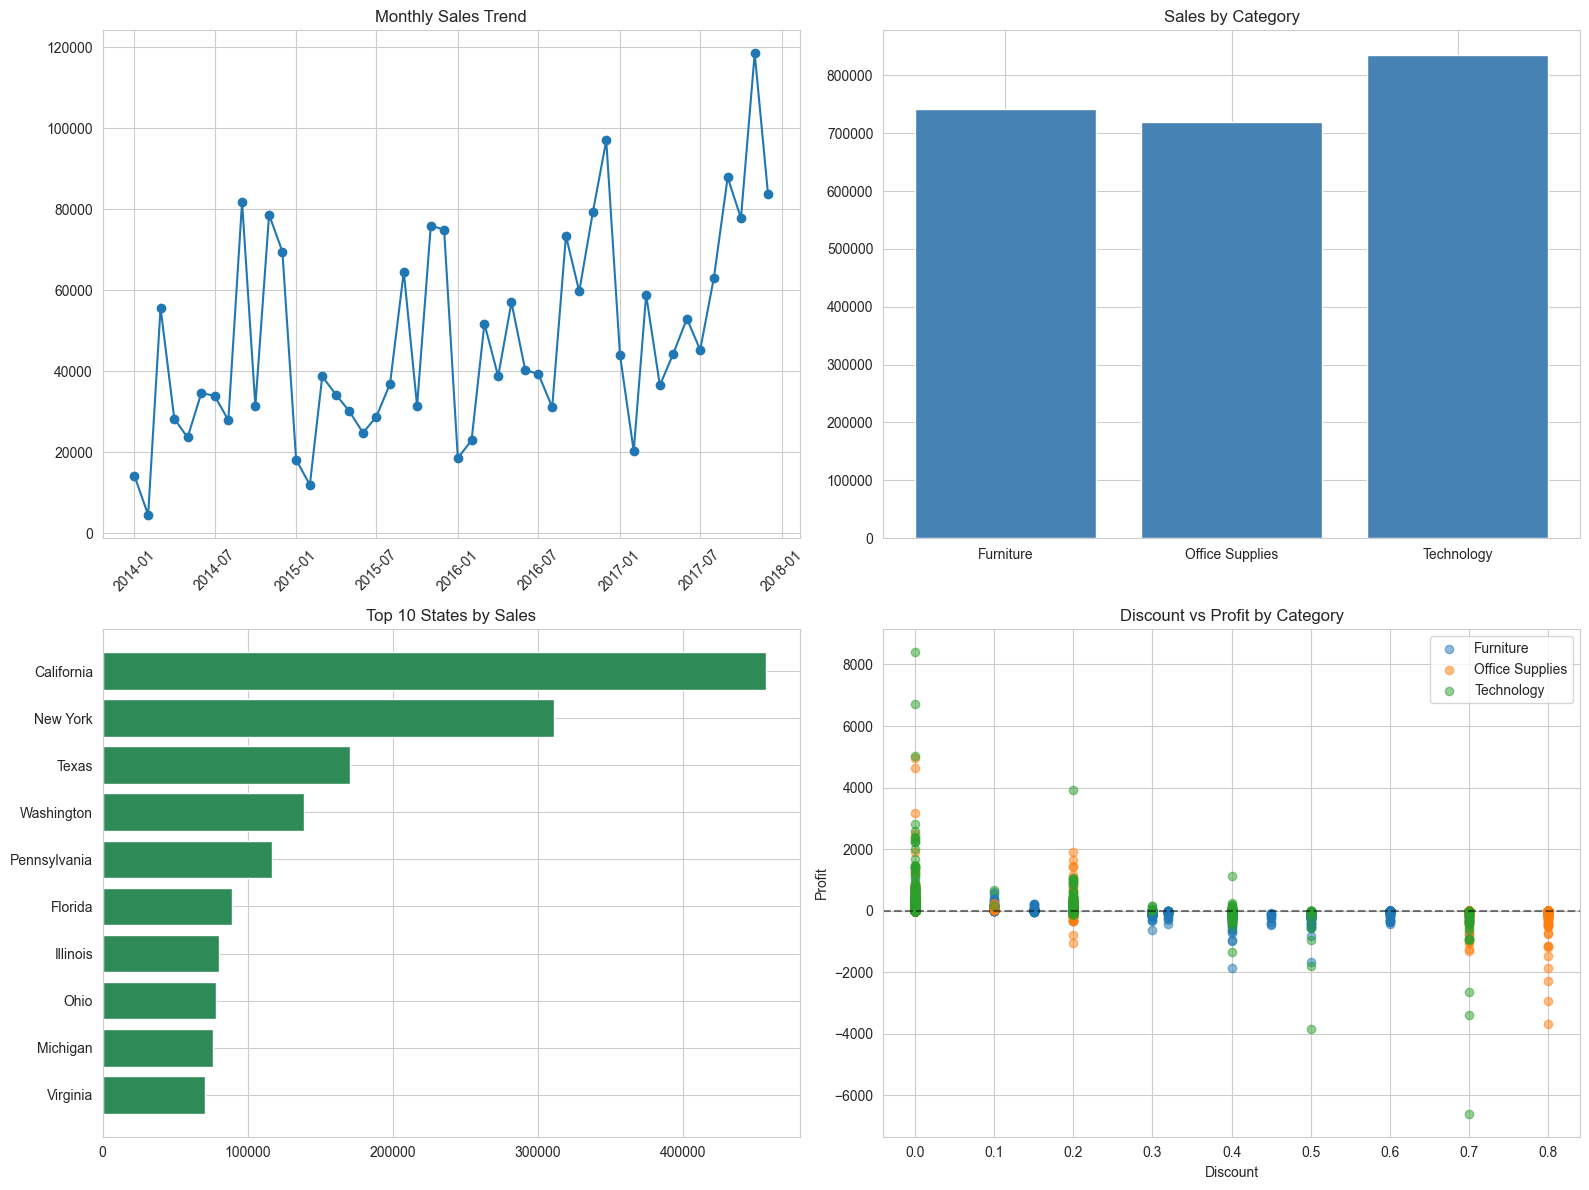

In [15]:
def create_dashboard():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
    ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values, marker='o')
    ax1.set_title('Monthly Sales Trend')
    ax1.tick_params(axis='x', rotation=45)

    category_sales = df.groupby('Category')['Sales'].sum()
    ax2.bar(category_sales.index, category_sales.values, color='steelblue')
    ax2.set_title('Sales by Category')

    top_10_states = state_sales.tail(10)
    ax3.barh(range(len(top_10_states)), top_10_states.values, color='seagreen')
    ax3.set_yticks(range(len(top_10_states)))
    ax3.set_yticklabels(top_10_states.index)
    ax3.set_title('Top 10 States by Sales')

    for category in df['Category'].unique():
        cat_data = df[df['Category'] == category]
        ax4.scatter(cat_data['Discount'], cat_data['Profit'], label=category, alpha=0.5)
    ax4.set_xlabel('Discount')
    ax4.set_ylabel('Profit')
    ax4.set_title('Discount vs Profit by Category')
    ax4.legend()
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

create_dashboard()

### 6.2 Outlier annotations on Discount vs Profit

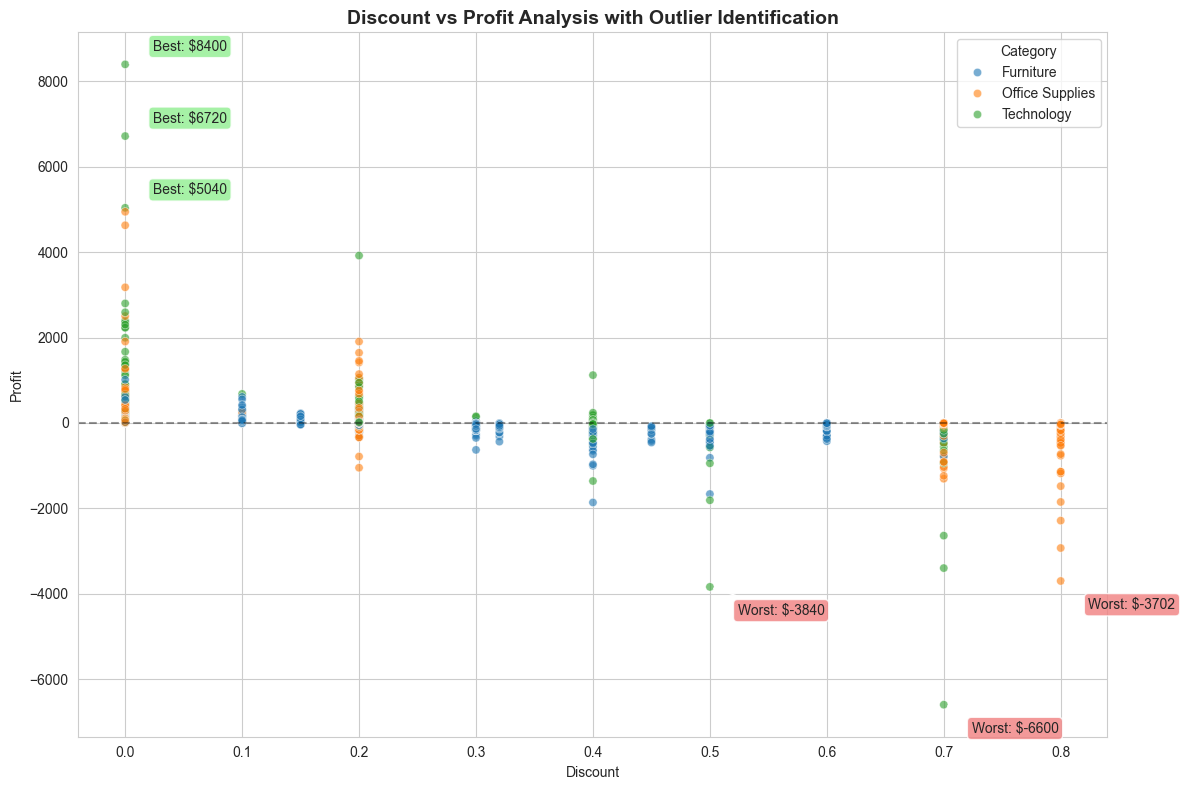

In [16]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)

top_3 = df.nlargest(3, 'Profit')
bottom_3 = df.nsmallest(3, 'Profit')

for _, row in top_3.iterrows():
    plt.annotate(f'Best: ${row["Profit"]:.0f}',
                 xy=(row['Discount'], row['Profit']),
                 xytext=(20, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

for _, row in bottom_3.iterrows():
    plt.annotate(f'Worst: ${row["Profit"]:.0f}',
                 xy=(row['Discount'], row['Profit']),
                 xytext=(20, -20), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.8),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.axhline(y=0, color='black', linestyle='--', alpha=0.4)
plt.title('Discount vs Profit Analysis with Outlier Identification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Plotly Express version of the Discount vs Profit chart

In [18]:
try:
    import plotly.express as px
    fig = px.scatter(df, x='Discount', y='Profit', color='Category',
                     hover_data=['Product Name', 'Sales'],
                     title='Interactive Discount vs Profit Analysis (Plotly)',
                     opacity=0.6)
    fig.add_hline(y=0, line_dash='dash', line_color='black')
    try:
        fig.show()
    except ValueError as e:
        # Inline Jupyter rendering requires nbformat>=4.2.0.
        # Fall back to saving an interactive HTML file.
        out_path = 'discount_vs_profit_plotly.html'
        fig.write_html(out_path)
        print(f"Inline Plotly rendering unavailable ({e}).")
        print(f"Interactive chart saved to: {out_path}")
        print("To enable inline display, run: pip install -U nbformat")
except ImportError:
    print("Plotly not installed. Run: pip install plotly nbformat")

print("\nPLOTLY vs MATPLOTLIB + ipywidgets COMPARISON:\n")
print("Plotly advantages:")
print("• Built-in interactivity (zoom, pan, hover tooltips)")
print("• Easy to export/share as standalone HTML")
print("• Responsive design out of the box\n")
print("Matplotlib + ipywidgets advantages:")
print("• Far more granular customization")
print("• Lighter weight; smaller notebook file sizes")
print("• More familiar to the broader Python data-science ecosystem")

Inline Plotly rendering unavailable (Mime type rendering requires nbformat>=4.2.0 but it is not installed).
Interactive chart saved to: discount_vs_profit_plotly.html
To enable inline display, run: pip install -U nbformat

PLOTLY vs MATPLOTLIB + ipywidgets COMPARISON:

Plotly advantages:
• Built-in interactivity (zoom, pan, hover tooltips)
• Easy to export/share as standalone HTML
• Responsive design out of the box

Matplotlib + ipywidgets advantages:
• Far more granular customization
• Lighter weight; smaller notebook file sizes
• More familiar to the broader Python data-science ecosystem
